## Access Station Lucinda Jetty Daily Satlantic-Hyperocr Derived Product (Zarr)
This Jupyter notebook demonstrates how to access and plot station_lucinda_jetty_daily_satlantic_hyperocr_derived_product data, available as a [Zarr](https://zarr.dev/) dataset stored on S3.

🔗 More information about the dataset is available [in the AODN metadata catalogue](https://catalogue-imos.aodn.org.au/geonetwork/srv/eng/catalog.search#/metadata/4ac6bf81-cd37-4611-8da8-4d5ae5e2bda3).

📌 The source of truth for this notebook is maintained on [GitHub](https://github.com/aodn/aodn_cloud_optimised/tree/main/notebooks/station_lucinda_jetty_daily_satlantic-hyperocr_derived_product.ipynb).


In [14]:
dataset_name = "station_lucinda_jetty_daily_satlantic_hyperocr_derived_product"

## Install/Update packages and Load common functions

In [2]:
import os, requests, importlib.util

open('setup.py', 'w').write(requests.get('https://raw.githubusercontent.com/aodn/aodn_cloud_optimised/main/notebooks/setup.py').text)

spec = importlib.util.spec_from_file_location("setup", "setup.py")
setup = importlib.util.module_from_spec(spec)
spec.loader.exec_module(setup)

setup.install_requirements()
setup.load_dataquery()

✅ Virtual environment already exists, skipping creation.


Using Python 3.12.6 environment at: /home/lbesnard/github_repo/aodn_cloud_optimised/.venv
Resolved 155 packages in 121ms
Checked 155 packages in 2ms


✅ Local version 0.3.13 is up to date (remote: 0.3.13)


In [3]:
from DataQuery import GetAodn

/home/lbesnard/github_repo/aodn_cloud_optimised/notebooks/DataQuery.py:4063: UserWarning: registration of accessor <class 'DataQuery.AODNAccessor'> under name 'aodn' for type <class 'pandas.core.frame.DataFrame'> is overriding a preexisting attribute with the same name.
  @pd.api.extensions.register_dataframe_accessor("aodn")


# Understanding the Dataset

In [4]:
# remote zarr dataset
aodn = GetAodn(bucket_name="imos-data-lab-optimised")
dname = f'{dataset_name}.zarr'
%time aodn_dataset = aodn.get_dataset(dname)

CPU times: user 276 ms, sys: 37.6 ms, total: 313 ms
Wall time: 781 ms


In [5]:
ds = aodn_dataset.zarr_store
ds.info()

xarray.Dataset {
dimensions:
	WAVELENGTH = 461 ;
	TIME = 39776 ;

variables:
	float64 LATITUDE() ;
		LATITUDE:axis = Y ;
		LATITUDE:long_name = latitude ;
		LATITUDE:reference_datum = geographical coordinates, WGS84 projection ;
		LATITUDE:standard_name = latitude ;
		LATITUDE:units = degrees_north ;
		LATITUDE:valid_max = 90.0 ;
		LATITUDE:valid_min = -90.0 ;
	float64 LONGITUDE() ;
		LONGITUDE:axis = X ;
		LONGITUDE:long_name = longitude ;
		LONGITUDE:reference_datum = geographical coordinates, WGS84 projection ;
		LONGITUDE:standard_name = longitude ;
		LONGITUDE:units = degrees_east ;
		LONGITUDE:valid_max = 180.0 ;
		LONGITUDE:valid_min = -180.0 ;
	float64 Rrs(WAVELENGTH, TIME) ;
		Rrs:ancillary_variables = Rrs_xflags Rrs_sd n_in_bin relaz sza windspeed ;
		Rrs:cell_method = LATITUDE: LONGITUDE: TIME: point ;
		Rrs:intercept = 0.0 ;
		Rrs:long_name = Median Remote Sensing Reflectance ;
		Rrs:slope = 1.0 ;
		Rrs:units = sr^-1 ;
		Rrs:varname = Rrs ;
	float64 Rrs_sd(WAVELENGTH, TIME)

## Plot time coverage

In [6]:
aodn_dataset.get_temporal_extent()

(Timestamp('2019-09-18 05:12:29.999858176'),
 Timestamp('2021-11-23 23:57:30.001146112'))

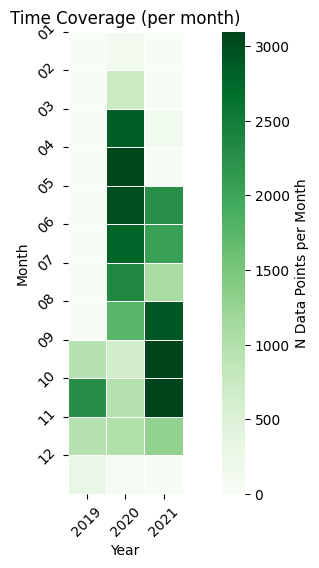

In [7]:
aodn_dataset.plot_time_coverage()

## Load Rrs Data

Access the Zarr store and load the Remote Sensing Reflectance (Rrs) dataset.
The data covers 350–810 nm at 1 nm resolution (~5-min sub-daily sampling, already QC'd at FV02 level).


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")

xds = aodn_dataset.zarr_store

# Auto-detect available time range
time_vals = xds["TIME"].values
t_min = pd.Timestamp(time_vals[0]).strftime("%Y-%m-%d")
t_max = pd.Timestamp(time_vals[-1]).strftime("%Y-%m-%d")
print(f"Dataset: {xds.dims['TIME']:,} time steps from {t_min} to {t_max}")
print(f"Wavelength range: {float(xds['WAVELENGTH'].min()):.0f}–{float(xds['WAVELENGTH'].max()):.0f} nm ({xds.dims['WAVELENGTH']} bands)")
print(xds["Rrs"])


Dataset: 39,776 time steps from 2019-09-18 to 2021-11-23
Wavelength range: 350–810 nm (461 bands)
<xarray.DataArray 'Rrs' (WAVELENGTH: 461, TIME: 39776)> Size: 147MB
[18336736 values with dtype=float64]
Coordinates:
    LATITUDE    float64 8B ...
    LONGITUDE   float64 8B ...
  * TIME        (TIME) datetime64[ns] 318kB 2019-09-18T05:12:29.999858176 ......
  * WAVELENGTH  (WAVELENGTH) float64 4kB 350.0 351.0 352.0 ... 808.0 809.0 810.0
    relaz       float64 8B ...
    sza         (TIME) float64 318kB ...
    windspeed   (TIME) float64 318kB ...
Attributes:
    ancillary_variables:  Rrs_xflags Rrs_sd n_in_bin relaz sza windspeed
    cell_method:          LATITUDE: LONGITUDE: TIME: point
    intercept:            0.0
    long_name:            Median Remote Sensing Reflectance
    slope:                1.0
    units:                sr^-1
    varname:              Rrs


## Rrs Hyperspectral Signatures

Full 350–810 nm Remote Sensing Reflectance spectra on selected dates.
Vertical dashed lines mark standard ocean colour satellite band centres
(MODIS Aqua in blue, Sentinel-3 OLCI in orange, PACE OCI in green).

A green-peaked, low-blue spectrum is characteristic of turbid coastal water
dominated by sediment resuspension and CDOM at Lucinda Jetty.


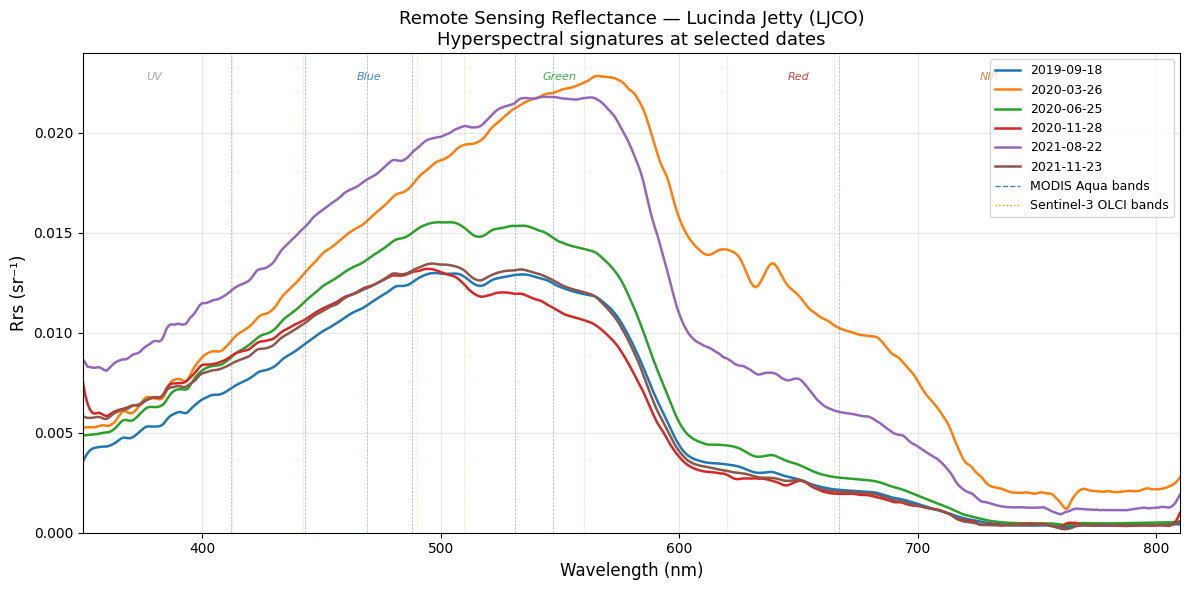

In [9]:
# --- pick a handful of representative dates across the record ---
DATE_START = ""   # leave empty to auto-detect
DATE_END   = ""

t_vals  = xds["TIME"].values
t_min_d = pd.Timestamp(t_vals[0]).strftime("%Y-%m-%d")
t_max_d = pd.Timestamp(t_vals[-1]).strftime("%Y-%m-%d")
DATE_START = DATE_START or t_min_d
DATE_END   = DATE_END   or t_max_d

# build a small sample: one representative spectrum per year
wl  = xds["WAVELENGTH"].values
rrs_da = xds["Rrs"].sel(TIME=slice(DATE_START, DATE_END))

# daily median across sub-daily measurements
rrs_daily = rrs_da.resample(TIME="1D").median("TIME")

# pick roughly 6 evenly-spaced dates that have valid data
good_times = rrs_daily.TIME.values[
    np.where(~np.all(np.isnan(rrs_daily.values), axis=0))[0]
]
n_show = min(6, len(good_times))
pick_idx = np.linspace(0, len(good_times) - 1, n_show, dtype=int)
sample_times = good_times[pick_idx]

# --- satellite band positions ---
MODIS_BANDS  = [412, 443, 469, 488, 531, 547, 667]
OLCI_BANDS   = [412.5, 442.5, 490, 510, 560, 620, 665]
PACE_BANDS   = list(range(340, 891, 10))  # OCI continuous

fig, ax = plt.subplots(figsize=(12, 6))
cmap = plt.get_cmap("tab10")

for i, t in enumerate(sample_times):
    spec = rrs_daily.sel(TIME=t, method="nearest").values
    label = pd.Timestamp(t).strftime("%Y-%m-%d")
    ax.plot(wl, spec, color=cmap(i), lw=1.8, label=label)

# annotate key satellite bands
for b in MODIS_BANDS:
    ax.axvline(b, color="steelblue", lw=0.5, ls="--", alpha=0.6)
for b in OLCI_BANDS:
    ax.axvline(b, color="darkorange", lw=0.5, ls=":", alpha=0.6)

# legend entries for bands
ax.axvline(np.nan, color="steelblue",  lw=1, ls="--", label="MODIS Aqua bands")
ax.axvline(np.nan, color="darkorange", lw=1, ls=":",  label="Sentinel-3 OLCI bands")

# annotate wavelength regions
for xpos, txt, col in [(380, "UV", "#aaa"), (470, "Blue", "#4488cc"),
                        (550, "Green", "#44aa44"), (650, "Red", "#cc4444"),
                        (730, "NIR", "#cc8844")]:
    ax.text(xpos, ax.get_ylim()[1] * 0.96 if ax.get_ylim()[1] > 0 else 0.018,
            txt, ha="center", va="top", fontsize=8, color=col, style="italic")

ax.set_xlabel("Wavelength (nm)", fontsize=12)
ax.set_ylabel("Rrs (sr⁻¹)", fontsize=12)
ax.set_title("Remote Sensing Reflectance — Lucinda Jetty (LJCO)\nHyperspectral signatures at selected dates", fontsize=13)
ax.set_xlim(350, 810)
ax.set_ylim(bottom=0)
ax.legend(fontsize=9, loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Rrs Hovmöller Diagram

Wavelength–time heatmap of daily median Rrs.
Seasonal patterns in the spectral shape reveal changes in water optical properties
(turbidity, phytoplankton, CDOM) throughout the year.


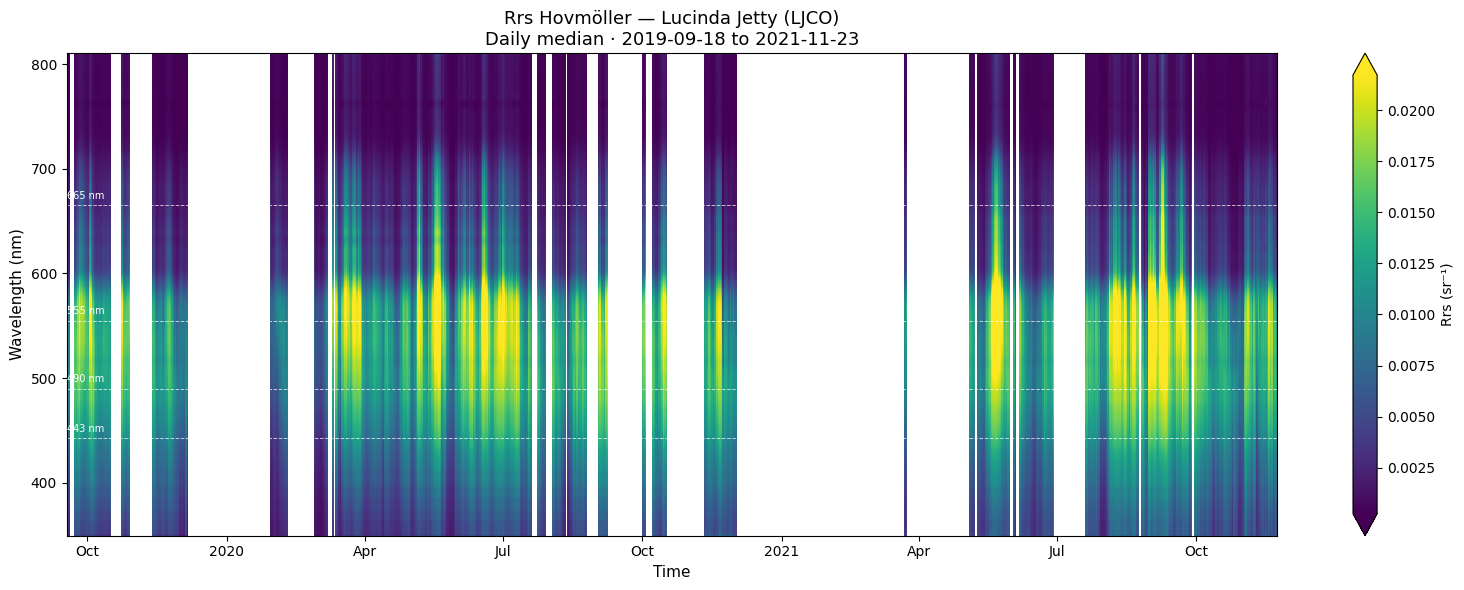

In [10]:
DATE_START = ""
DATE_END   = ""
t_vals = xds["TIME"].values
DATE_START = DATE_START or pd.Timestamp(t_vals[0]).strftime("%Y-%m-%d")
DATE_END   = DATE_END   or pd.Timestamp(t_vals[-1]).strftime("%Y-%m-%d")

# Daily median → shape (WAVELENGTH, TIME)
rrs_da   = xds["Rrs"].sel(TIME=slice(DATE_START, DATE_END))
rrs_daily = rrs_da.resample(TIME="1D").median("TIME").astype(float)

fig, ax = plt.subplots(figsize=(16, 6))
rrs_daily.plot(
    x="TIME", y="WAVELENGTH",
    ax=ax, robust=True,
    cmap="viridis",
    cbar_kwargs={"label": "Rrs (sr⁻¹)"},
)
ax.set_title(
    "Rrs Hovmöller — Lucinda Jetty (LJCO)\n"
    f"Daily median · {DATE_START} to {DATE_END}",
    fontsize=13,
)
ax.set_xlabel("Time", fontsize=11)
ax.set_ylabel("Wavelength (nm)", fontsize=11)

# mark key wavelengths
for wl_mark, lbl in [(443, "443"), (490, "490"), (555, "555"), (665, "665")]:
    ax.axhline(wl_mark, color="white", lw=0.7, ls="--", alpha=0.7)
    ax.text(pd.Timestamp(DATE_START), wl_mark + 4, lbl + " nm",
            color="white", fontsize=7, va="bottom")

plt.tight_layout()
plt.show()


## Rrs at Key Ocean-Colour Wavelengths

Time series of Rrs at four standard ocean-colour channels:
- **443 nm** — phytoplankton absorption maximum (blue)
- **490 nm** — mixed CDOM + scattering channel (blue-green)
- **555 nm** — total scattering / green reference (green)
- **665 nm** — chlorophyll *a* red absorption trough (red)

Points are coloured by solar zenith angle (sza); lighter colours indicate
measurements taken close to local noon (low sza = high solar elevation).


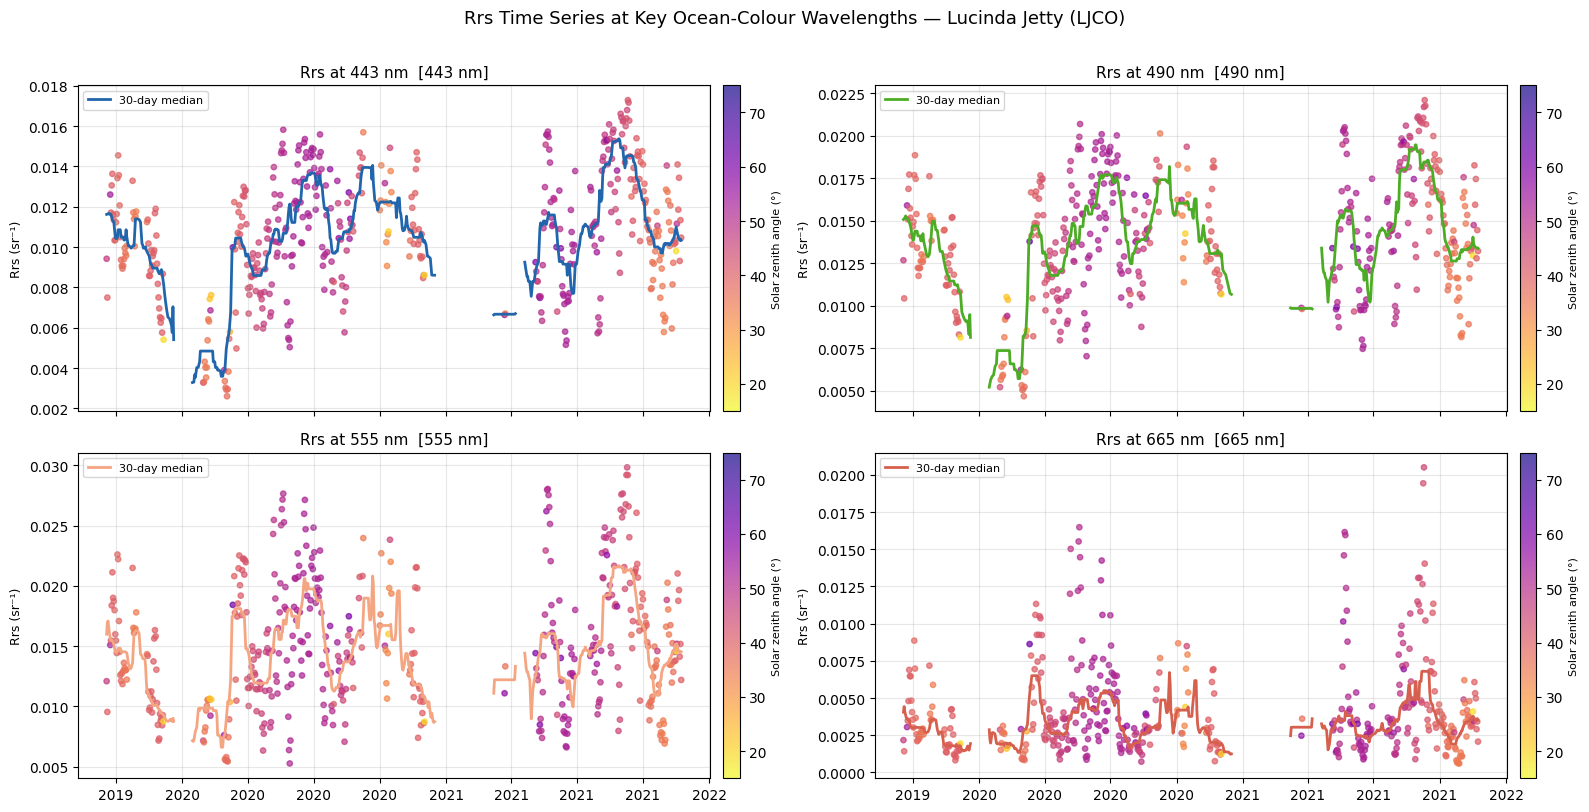

In [11]:
DATE_START = ""
DATE_END   = ""
t_vals = xds["TIME"].values
DATE_START = DATE_START or pd.Timestamp(t_vals[0]).strftime("%Y-%m-%d")
DATE_END   = DATE_END   or pd.Timestamp(t_vals[-1]).strftime("%Y-%m-%d")

KEY_WL = {"443 nm": 443, "490 nm": 490, "555 nm": 555, "665 nm": 665}
colors = {"443 nm": "#2166ac", "490 nm": "#4dac26", "555 nm": "#f4a582", "665 nm": "#d6604d"}

wl_arr = xds["WAVELENGTH"].values
sub = xds.sel(TIME=slice(DATE_START, DATE_END))

# Daily median
rrs_daily = sub["Rrs"].resample(TIME="1D").median("TIME").astype(float)
sza_daily = sub["sza"].resample(TIME="1D").mean("TIME").astype(float)

fig, axes = plt.subplots(2, 2, figsize=(16, 8), sharex=True)
axes = axes.flatten()

for ax, (label, target_wl) in zip(axes, KEY_WL.items()):
    idx = int(np.argmin(np.abs(wl_arr - target_wl)))
    actual_wl = wl_arr[idx]
    rrs_ts = rrs_daily.isel(WAVELENGTH=idx).values
    sza_ts = sza_daily.values
    t_ts   = rrs_daily.TIME.values

    valid = ~np.isnan(rrs_ts) & ~np.isnan(sza_ts)
    sc = ax.scatter(
        t_ts[valid], rrs_ts[valid],
        c=sza_ts[valid], cmap="plasma_r", s=15, alpha=0.7,
        vmin=15, vmax=75,
    )
    # 30-day rolling median
    df = pd.Series(rrs_ts, index=pd.to_datetime(t_ts))
    rolling = df.rolling("30D", center=True).median()
    ax.plot(rolling.index, rolling.values, color=colors[label], lw=2, label="30-day median")

    cb = plt.colorbar(sc, ax=ax, fraction=0.03, pad=0.02)
    cb.set_label("Solar zenith angle (°)", fontsize=8)
    ax.set_title(f"Rrs at {actual_wl:.0f} nm  [{label}]", fontsize=11)
    ax.set_ylabel("Rrs (sr⁻¹)", fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.suptitle(
    "Rrs Time Series at Key Ocean-Colour Wavelengths — Lucinda Jetty (LJCO)",
    fontsize=13, y=1.01,
)
plt.tight_layout()
plt.show()


## Ocean-Colour Band Ratios

Band ratios are proxies for key water-quality parameters:

| Ratio | Proxy |
|---|---|
| Rrs(490) / Rrs(555) | Turbidity / CDOM index — higher values = clearer water |
| Rrs(443) / Rrs(555) | Phytoplankton / CDOM absorption — lower values = more absorption |

These ratios underpin empirical satellite chlorophyll algorithms
(OC3, OC4, MODIS, Sentinel-3) and can be directly compared to satellite-derived products.


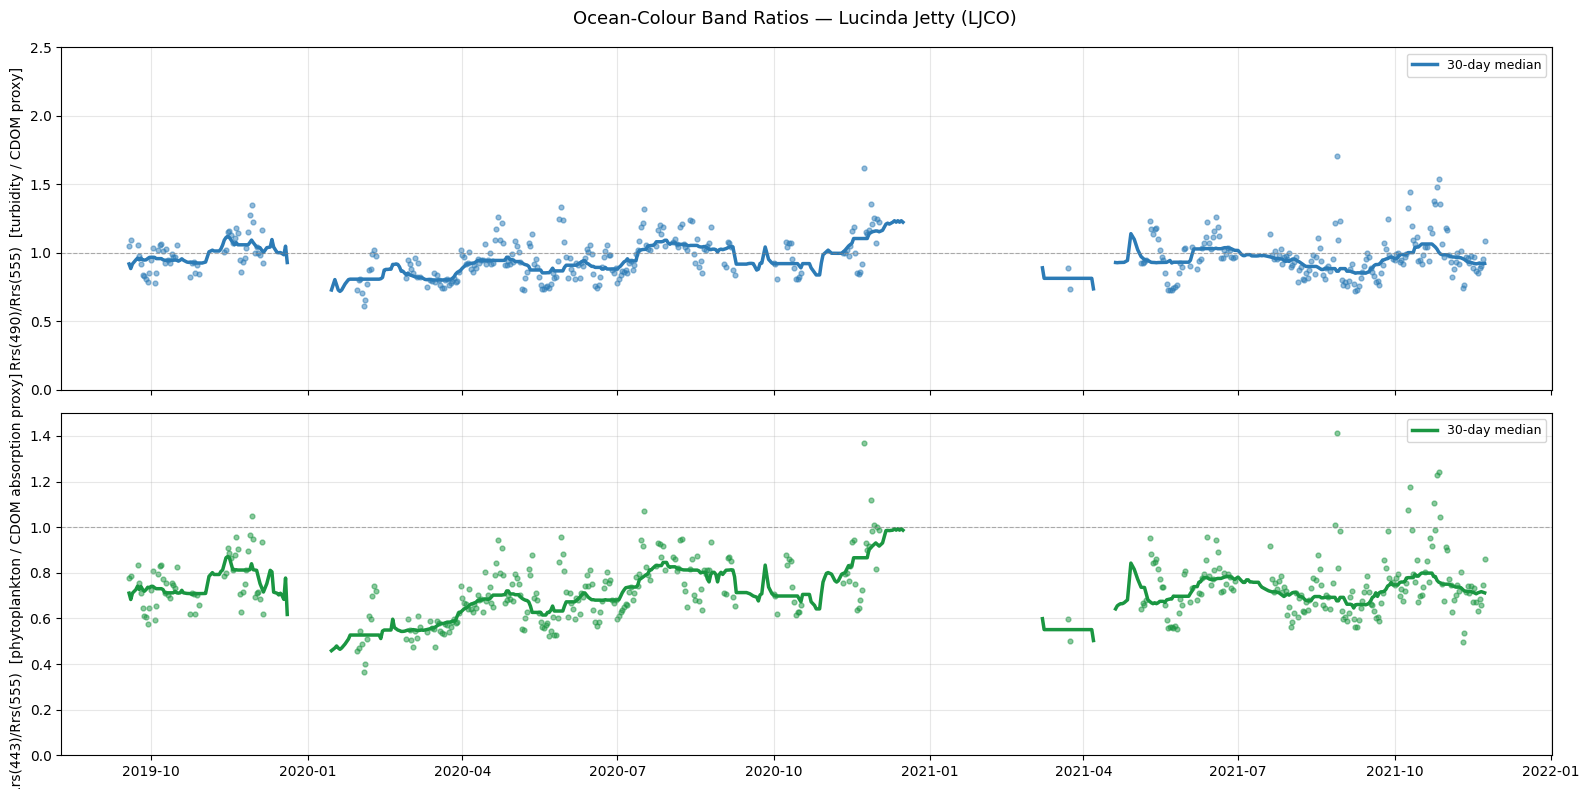

In [12]:
DATE_START = ""
DATE_END   = ""
t_vals = xds["TIME"].values
DATE_START = DATE_START or pd.Timestamp(t_vals[0]).strftime("%Y-%m-%d")
DATE_END   = DATE_END   or pd.Timestamp(t_vals[-1]).strftime("%Y-%m-%d")

wl_arr = xds["WAVELENGTH"].values
sub = xds.sel(TIME=slice(DATE_START, DATE_END))
rrs_daily = sub["Rrs"].resample(TIME="1D").median("TIME").astype(float)

def rrs_at(wl_target):
    idx = int(np.argmin(np.abs(wl_arr - wl_target)))
    return rrs_daily.isel(WAVELENGTH=idx).values

rrs_443 = rrs_at(443); rrs_490 = rrs_at(490); rrs_555 = rrs_at(555)
t_daily = pd.to_datetime(rrs_daily.TIME.values)

ratio_490_555 = np.where(rrs_555 > 0, rrs_490 / rrs_555, np.nan)
ratio_443_555 = np.where(rrs_555 > 0, rrs_443 / rrs_555, np.nan)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

for ax, ratio, label, color, ylim in [
    (ax1, ratio_490_555, "Rrs(490)/Rrs(555)  [turbidity / CDOM proxy]", "#2c7bb6", (0, 2.5)),
    (ax2, ratio_443_555, "Rrs(443)/Rrs(555)  [phytoplankton / CDOM absorption proxy]", "#1a9641", (0, 1.5)),
]:
    valid = ~np.isnan(ratio)
    ax.scatter(t_daily[valid], ratio[valid], s=12, alpha=0.5, color=color)
    roll = pd.Series(ratio, index=t_daily).rolling("30D", center=True).median()
    ax.plot(roll.index, roll.values, color=color, lw=2.5, label="30-day median")
    ax.set_ylabel(label, fontsize=10)
    ax.set_ylim(ylim)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.axhline(1.0, color="grey", lw=0.8, ls="--", alpha=0.6)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

fig.suptitle(
    "Ocean-Colour Band Ratios — Lucinda Jetty (LJCO)",
    fontsize=13,
)
plt.tight_layout()
plt.show()


## Seasonal Mean Rrs Spectra

Mean (±1σ) Rrs spectra grouped by austral season:
- **DJF** (Dec–Feb) — tropical wet season: high turbidity, river runoff, CDOM
- **MAM** (Mar–May) — transition: declining turbidity
- **JJA** (Jun–Aug) — austral winter: clearer water, lower phytoplankton
- **SON** (Sep–Nov) — spring bloom onset

Satellite ocean-colour band centres are overlaid as vertical markers.


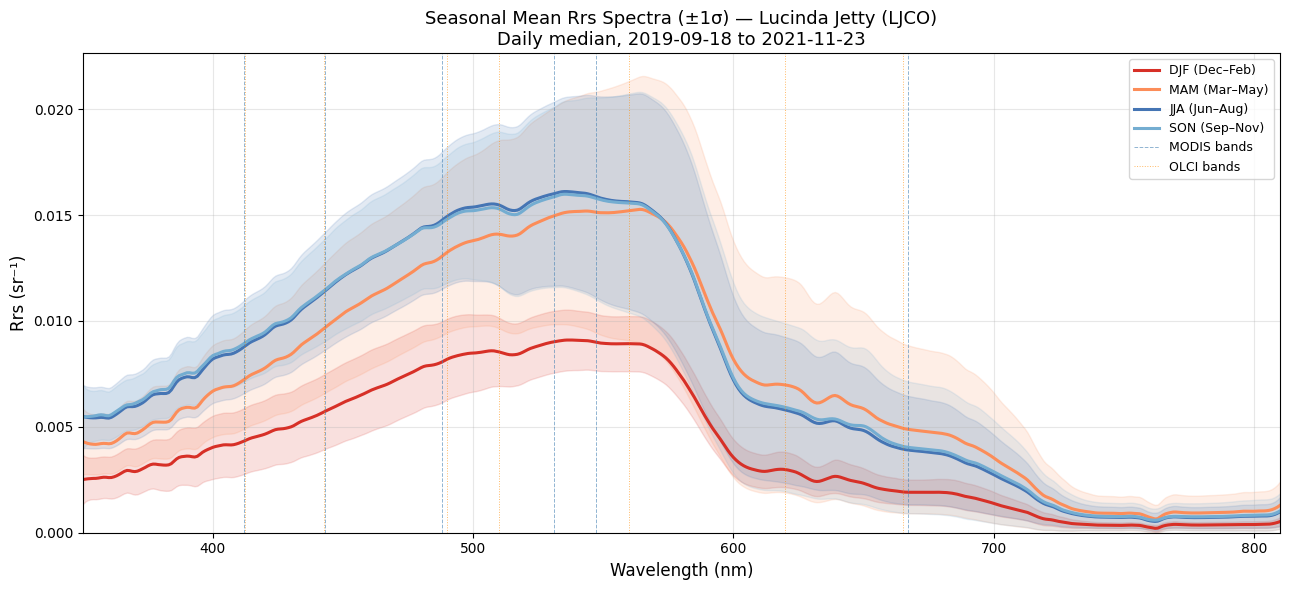

In [13]:
DATE_START = ""
DATE_END   = ""
t_vals = xds["TIME"].values
DATE_START = DATE_START or pd.Timestamp(t_vals[0]).strftime("%Y-%m-%d")
DATE_END   = DATE_END   or pd.Timestamp(t_vals[-1]).strftime("%Y-%m-%d")

wl_arr = xds["WAVELENGTH"].values
rrs_da = xds["Rrs"].sel(TIME=slice(DATE_START, DATE_END))
rrs_daily = rrs_da.resample(TIME="1D").median("TIME").astype(float)

seasons = {
    "DJF (Dec–Feb)": [12, 1, 2],
    "MAM (Mar–May)": [3, 4, 5],
    "JJA (Jun–Aug)": [6, 7, 8],
    "SON (Sep–Nov)": [9, 10, 11],
}
season_colors = {"DJF (Dec–Feb)": "#d73027", "MAM (Mar–May)": "#fc8d59",
                 "JJA (Jun–Aug)": "#4575b4", "SON (Sep–Nov)": "#74add1"}

months = pd.to_datetime(rrs_daily.TIME.values).month
rrs_np = rrs_daily.values  # shape: (WAVELENGTH, TIME)

# satellite bands (wavelength, marker, colour)
SAT_BANDS = [
    (412,  "MODIS",  "steelblue"), (443, "MODIS",  "steelblue"),
    (488,  "MODIS",  "steelblue"), (531, "MODIS",  "steelblue"),
    (547,  "MODIS",  "steelblue"), (667, "MODIS",  "steelblue"),
    (412.5, "OLCI", "darkorange"), (442.5, "OLCI", "darkorange"),
    (490,  "OLCI",  "darkorange"), (510,  "OLCI",  "darkorange"),
    (560,  "OLCI",  "darkorange"), (620,  "OLCI",  "darkorange"),
    (665,  "OLCI",  "darkorange"),
]

fig, ax = plt.subplots(figsize=(13, 6))

drawn_labels = set()
for season, month_list in seasons.items():
    mask = np.isin(months, month_list)
    if mask.sum() == 0:
        continue
    season_rrs = rrs_np[:, mask]
    mean_spec = np.nanmean(season_rrs, axis=1)
    std_spec  = np.nanstd(season_rrs,  axis=1)
    color = season_colors[season]
    ax.plot(wl_arr, mean_spec, color=color, lw=2.2, label=season)
    ax.fill_between(wl_arr, mean_spec - std_spec, mean_spec + std_spec,
                    color=color, alpha=0.15)

# satellite band overlays
for wl_b, sat, col in SAT_BANDS:
    lbl = f"{sat} bands" if (sat, col) not in drawn_labels else "_"
    drawn_labels.add((sat, col))
    ax.axvline(wl_b, color=col, lw=0.7, ls="--" if sat == "MODIS" else ":", alpha=0.6,
               label=lbl)

ax.set_xlabel("Wavelength (nm)", fontsize=12)
ax.set_ylabel("Rrs (sr⁻¹)", fontsize=12)
ax.set_title(
    "Seasonal Mean Rrs Spectra (±1σ) — Lucinda Jetty (LJCO)\n"
    f"Daily median, {DATE_START} to {DATE_END}",
    fontsize=13,
)
ax.set_xlim(350, 810)
ax.set_ylim(bottom=0)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
